# **Importing Libraries And Dataset Characteritics**

In [ ]:
# Libraries used for data loading and manipulation
import pandas as pd
import numpy as np

# Libraries used for data cleaning and preparation
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Libraries used for model training
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Libraries used for model optimization and evaluation
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc, make_scorer

# Libraries used for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries used for model explainability
import shap
import lime
import lime.lime_tabular

In [ ]:
# Load the dataset
df = pd.read_csv('IBM-HR-Employee-Attrition.csv')

In [ ]:
# Show the first few rows of the dataset
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
# Show the last few rows of the dataset
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [ ]:
# Show descriptive information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
# Show descriptive statistics
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
# Check for missing values
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [ ]:
# Check for duplicated values
df.duplicated().sum()

np.int64(0)

In [ ]:
# Define the shape of the data
df.shape

(1470, 35)

In [ ]:
# Analyze the distribution of the target variable
display(df['Attrition'].value_counts())

,count
Attrition,
No,1233
Yes,237


# **Exploratory Data Analysis (EDA)**

Text(0.5, 1.0, 'Distribution of Age')

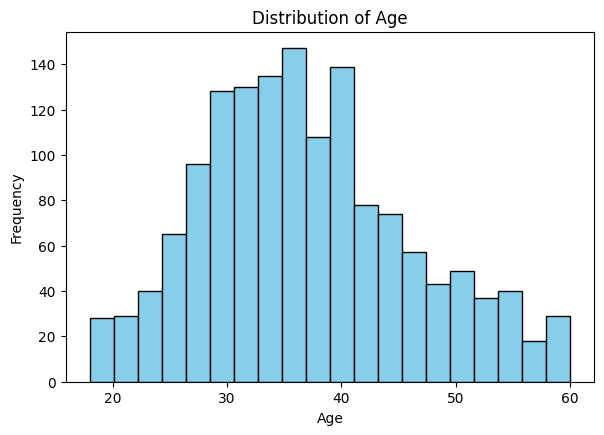

In [ ]:
# Explore distributions of key numerical variables

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')

Text(0.5, 1.0, 'Distribution of Job Satisfaction')

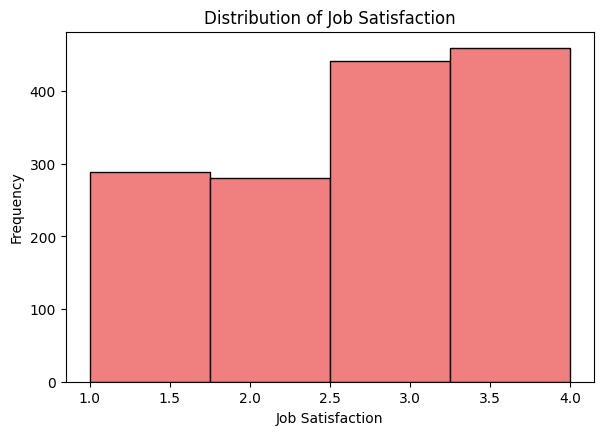

In [ ]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 2)
plt.hist(df['JobSatisfaction'], bins=4, color='lightcoral', edgecolor='black')
plt.xlabel('Job Satisfaction')
plt.ylabel('Frequency')
plt.title('Distribution of Job Satisfaction')

Text(0.5, 1.0, 'Distribution of Years at Company')

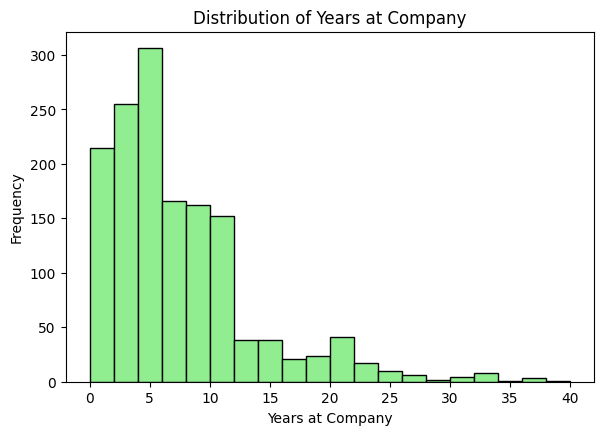

In [ ]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 3)
plt.hist(df['YearsAtCompany'], bins=20, color='lightgreen', edgecolor='black')
plt.xlabel('Years at Company')
plt.ylabel('Frequency')
plt.title('Distribution of Years at Company')

Text(0.5, 1.0, 'Distribution of Monthly Income')

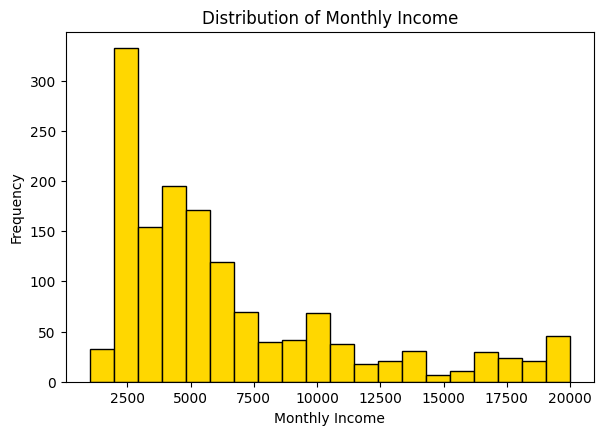

In [ ]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 4)
plt.hist(df['MonthlyIncome'], bins=20, color='gold', edgecolor='black')
plt.xlabel('Monthly Income')
plt.ylabel('Frequency')
plt.title('Distribution of Monthly Income')

In [ ]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

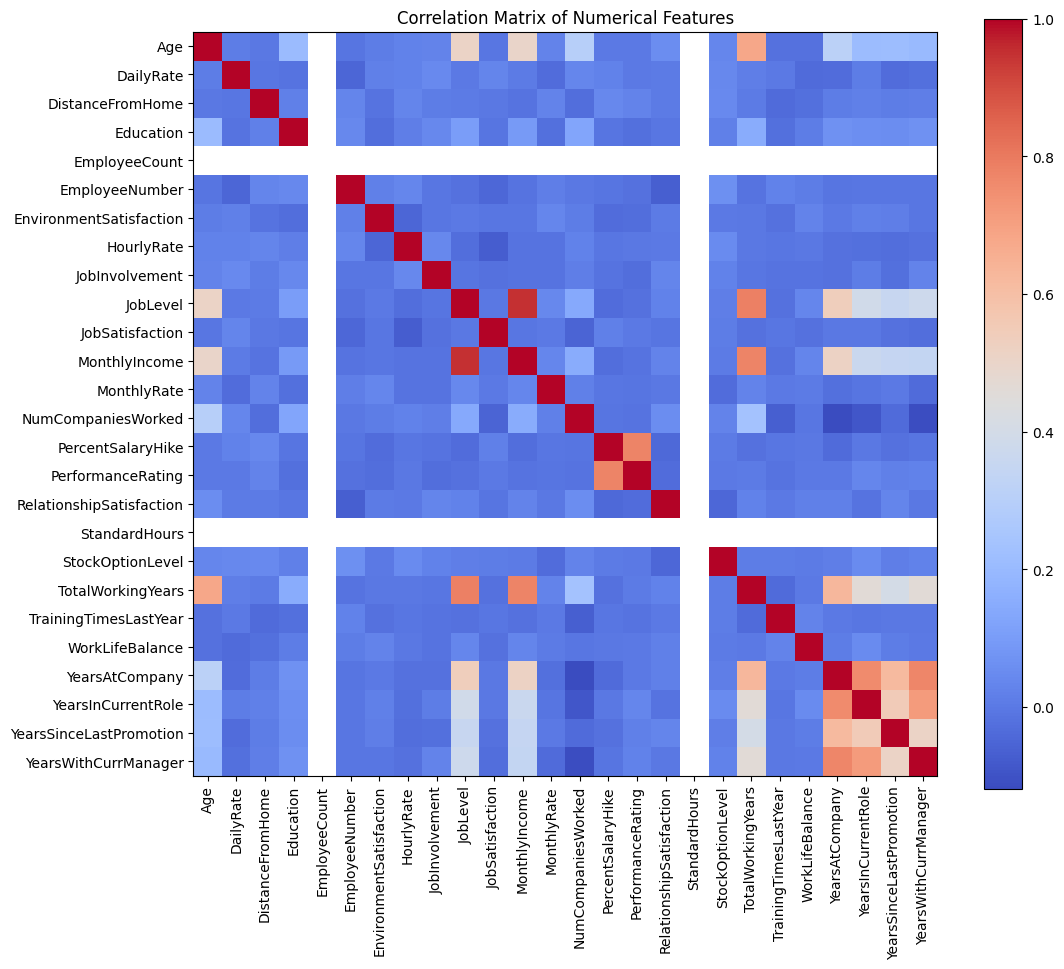

In [ ]:
# Calculate and visualize the correlation matrix of numerical columns
numerical_df = df.select_dtypes(include=['number'])
corr_matrix = numerical_df.corr()
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
# Convert 'Attrition' to numerical (0 for 'No', 1 for 'Yes')
le = LabelEncoder()
df['Attrition'] = le.fit_transform(df['Attrition'])

In [ ]:
# Identify and convert categorical columns using one-hot encoding
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'Attrition' in categorical_cols:
    categorical_cols.remove('Attrition')
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
# Outlier handling by Winsorizing
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
numerical_cols.remove('Attrition') # Exclude the target variable from outlier treatment
for col in numerical_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

In [ ]:
# Verify the data cleaning steps
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 48 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1470 non-null   int64  
 1   Attrition                          1470 non-null   int64  
 2   DailyRate                          1470 non-null   int64  
 3   DistanceFromHome                   1470 non-null   int64  
 4   Education                          1470 non-null   int64  
 5   EmployeeCount                      1470 non-null   int64  
 6   EmployeeNumber                     1470 non-null   int64  
 7   EnvironmentSatisfaction            1470 non-null   int64  
 8   HourlyRate                         1470 non-null   int64  
 9   JobInvolvement                     1470 non-null   int64  
 10  JobLevel                           1470 non-null   int64  
 11  JobSatisfaction                    1470 non-null   int64

(1470, 48)

# **Model Training, Optimization And Evaluation**

In [ ]:
# Define features (X) and target (y)
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
numerical_cols = X.select_dtypes(include=['number']).columns
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [ ]:
# Initialize Random Forest Classifier
rf_model = RandomForestClassifier()

# Initialize Logistic Regression model
lr_model = LogisticRegression(max_iter=2000) # Increased max_iter to ensure convergence

# Train the Random Forest model
rf_model.fit(X_train, y_train)

# Train the Logistic Regression model
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [ ]:
# Define the parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Define the parameter grid for Logistic Regression
lr_param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

In [ ]:
# Initialize GridSearchCV for Random Forest
rf_grid_search = GridSearchCV(estimator=rf_model, param_grid=rf_param_grid, scoring='roc_auc', cv=5)

# Initialize GridSearchCV for Logistic Regression
lr_grid_search = GridSearchCV(estimator=lr_model, param_grid=lr_param_grid, scoring='roc_auc', cv=5)

# Fit GridSearchCV to the training data for Random Forest
rf_grid_search.fit(X_train, y_train)

# Fit GridSearchCV to the training data for Logistic Regression
lr_grid_search.fit(X_train, y_train)

# Print the best hyperparameters for each model
print("Best hyperparameters for Random Forest:", rf_grid_search.best_params_)
print("Best hyperparameters for Logistic Regression:", lr_grid_search.best_params_)

# Store the best-performing models
best_rf_model = rf_grid_search.best_estimator_
best_lr_model = lr_grid_search.best_estimator_

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best hyperparameters for Random Forest: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Best hyperparameters for Logistic Regression: {'C': 1, 'penalty': 'l1', 'solver': 'saga'}


In [ ]:
# Predict on the test set
y_pred_rf = best_rf_model.predict(X_test)
y_pred_lr = best_lr_model.predict(X_test)

# Calculate evaluation metrics
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred)
    print(f"{model_name} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-score: {f1:.4f}")
    print(f"  AUC: {auc:.4f}")
    return accuracy, precision, recall, f1, auc

# Evaluate Random Forest
rf_metrics = evaluate_model(y_test, y_pred_rf, "Random Forest")

# Evaluate Logistic Regression
lr_metrics = evaluate_model(y_test, y_pred_lr, "Logistic Regression")


Random Forest Metrics:
  Accuracy: 0.8741
  Precision: 0.6667
  Recall: 0.1026
  F1-score: 0.1778
  AUC: 0.5474
Logistic Regression Metrics:
  Accuracy: 0.8776
  Precision: 0.5517
  Recall: 0.4103
  F1-score: 0.4706
  AUC: 0.6796


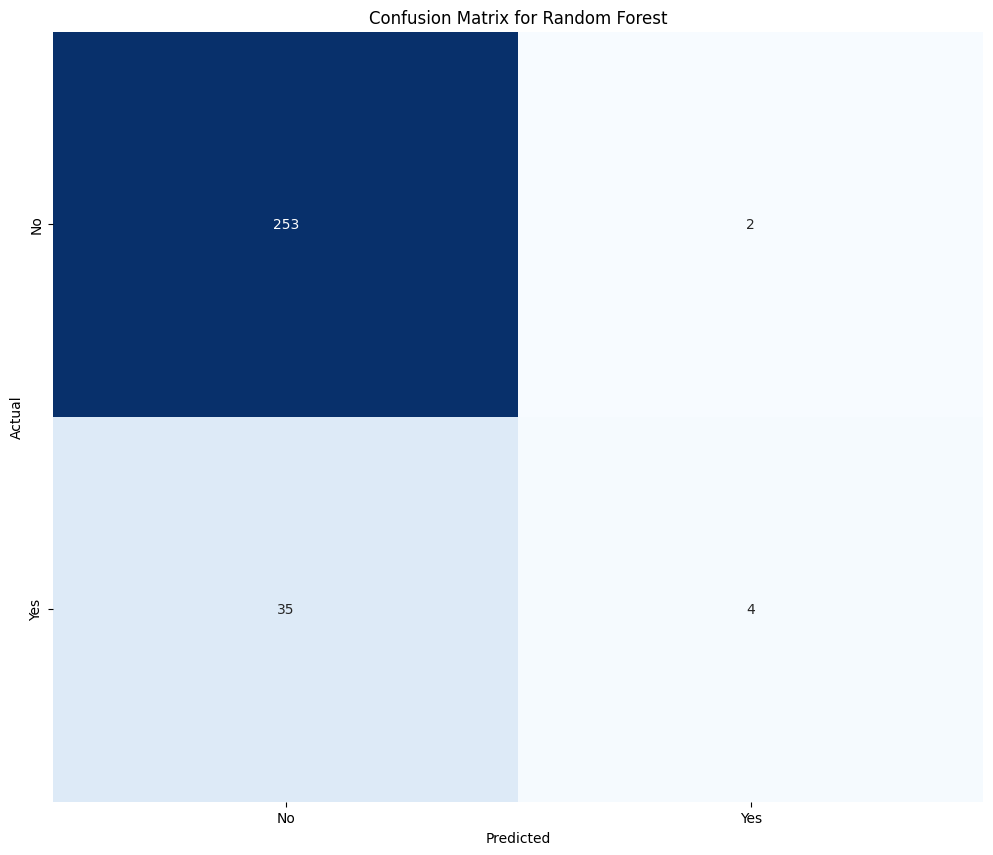

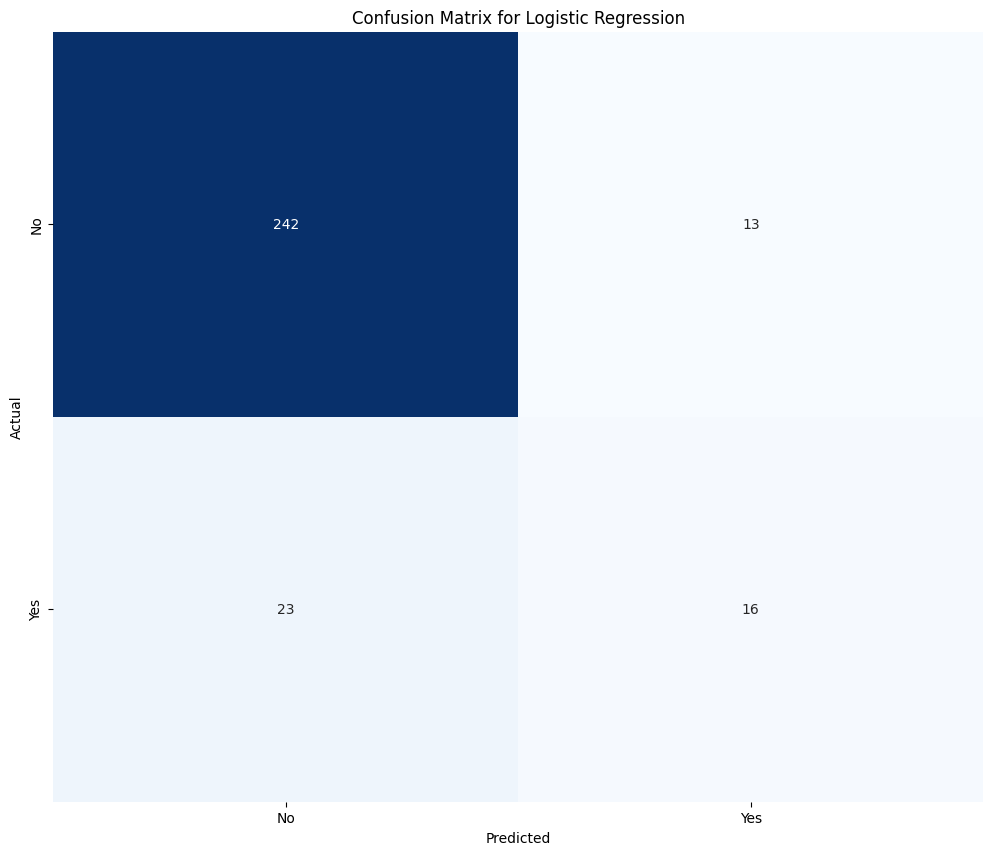

In [ ]:
# Confusion Matrices
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix for {model_name}")
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")
plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression")

# **Model Prediction and Results Using LIME**

In [ ]:
# Choose the best model to explain
model_to_explain = best_lr_model

# Prepare the data for LIME
feature_names = X_train.columns.tolist()

# Since we used one-hot encoding, we treat all features as continuous for LIME
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=['No Attrition', 'Attrition'],
    mode='classification'
)

# Explain an individual prediction
instance_idx = 0
instance_to_explain = X_test.iloc[instance_idx]

# Get the explanation for the chosen instance
explanation = explainer.explain_instance(
    data_row=instance_to_explain.values,
    predict_fn=model_to_explain.predict_proba,
    num_features=10 # You can adjust this number
)

# Visualize the LIME explanation
print(f"LIME Explanation for instance {instance_idx}:")
explanation.as_list()

LIME Explanation for instance 0:


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[('OverTime_Yes <= 0.00', -0.2256077360607889),
 ('BusinessTravel_Travel_Frequently <= 0.00', -0.1837382612926594),
 ('JobRole_Laboratory Technician <= 0.00', -0.14804208438960348),
 ('JobRole_Sales Representative <= 0.00', -0.1118611790388194),
 ('0.00 < MaritalStatus_Single <= 1.00', 0.10196788568665695),
 ('Department_Research & Development <= 0.00', 0.096636569740191),
 ('JobSatisfaction <= -0.67', 0.08211790749097547),
 ('NumCompaniesWorked <= -0.66', -0.07599889619414206),
 ('TotalWorkingYears <= -0.68', 0.06874563269966652),
 ('EducationField_Technical Degree <= 0.00', -0.06272850531297826)]

# **Visualizations**

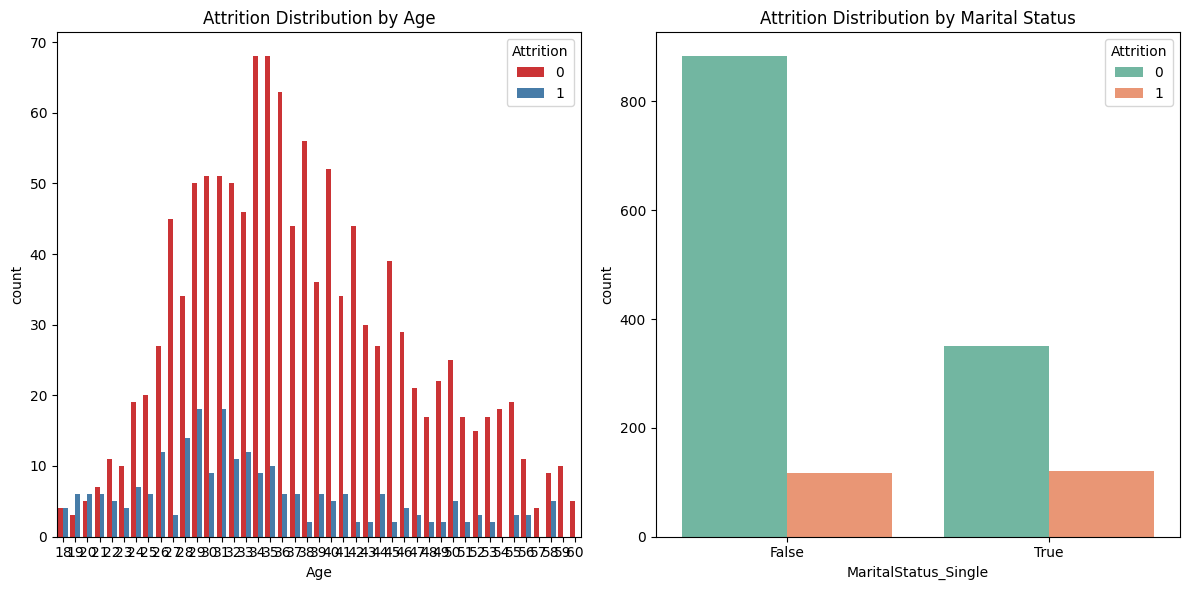

In [ ]:
# Distribution of Attrition across Demographics
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.countplot(x='Age', hue='Attrition', data=df, palette="Set1")
plt.title('Attrition Distribution by Age')
plt.subplot(1, 2, 2)
sns.countplot(x='MaritalStatus_Single', hue='Attrition', data=df, palette="Set2")
plt.title('Attrition Distribution by Marital Status')
plt.tight_layout()
plt.show()

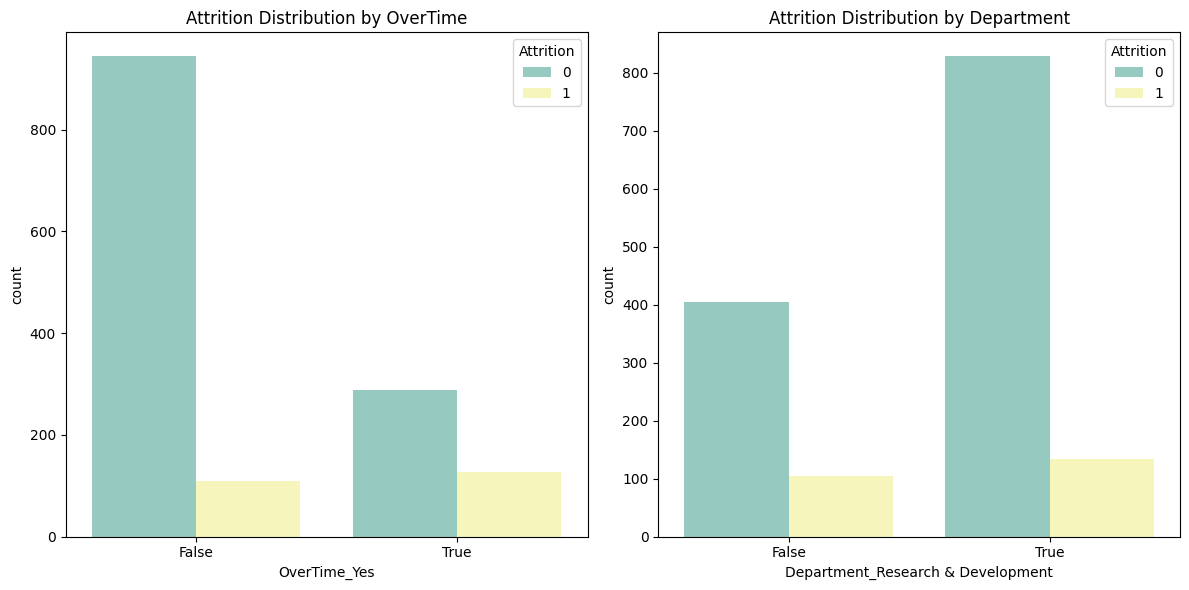

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.countplot(x='OverTime_Yes', hue='Attrition', data=df, palette="Set3")
plt.title('Attrition Distribution by OverTime')
plt.subplot(1, 2, 2)
sns.countplot(x='Department_Research & Development', hue='Attrition', data=df, palette="Set3")
plt.title('Attrition Distribution by Department')
plt.tight_layout()
plt.show()

<ipython-input-55-30034511a108>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette="Set1")
<ipython-input-55-30034511a108>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='YearsAtCompany', data=df, palette="Set2")


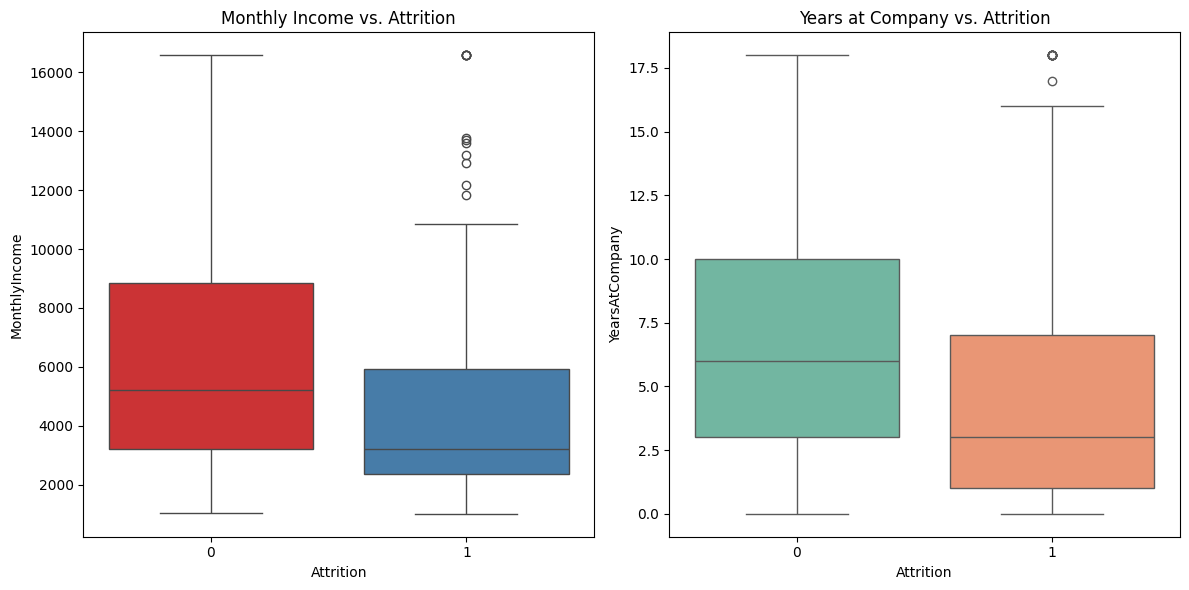

In [ ]:
# Relationship between Key Drivers and Attrition
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette="Set1")
plt.title('Monthly Income vs. Attrition')
plt.subplot(1, 2, 2)
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df, palette="Set2")
plt.title('Years at Company vs. Attrition')
plt.tight_layout()
plt.show()

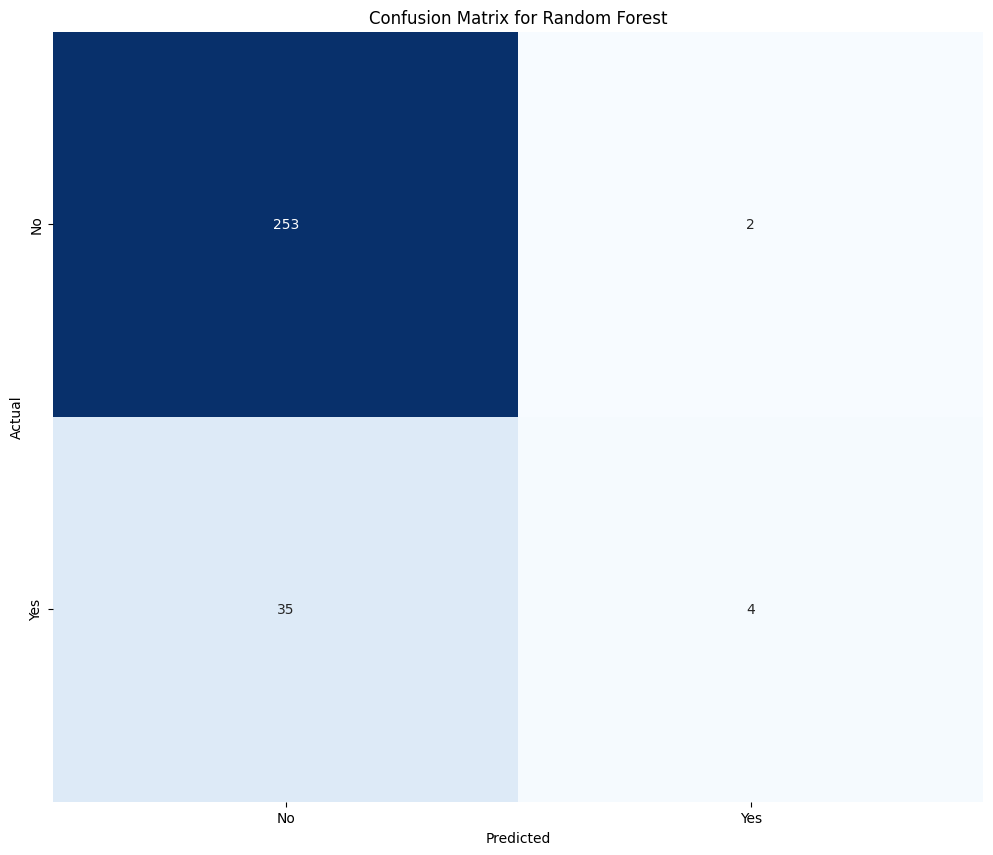

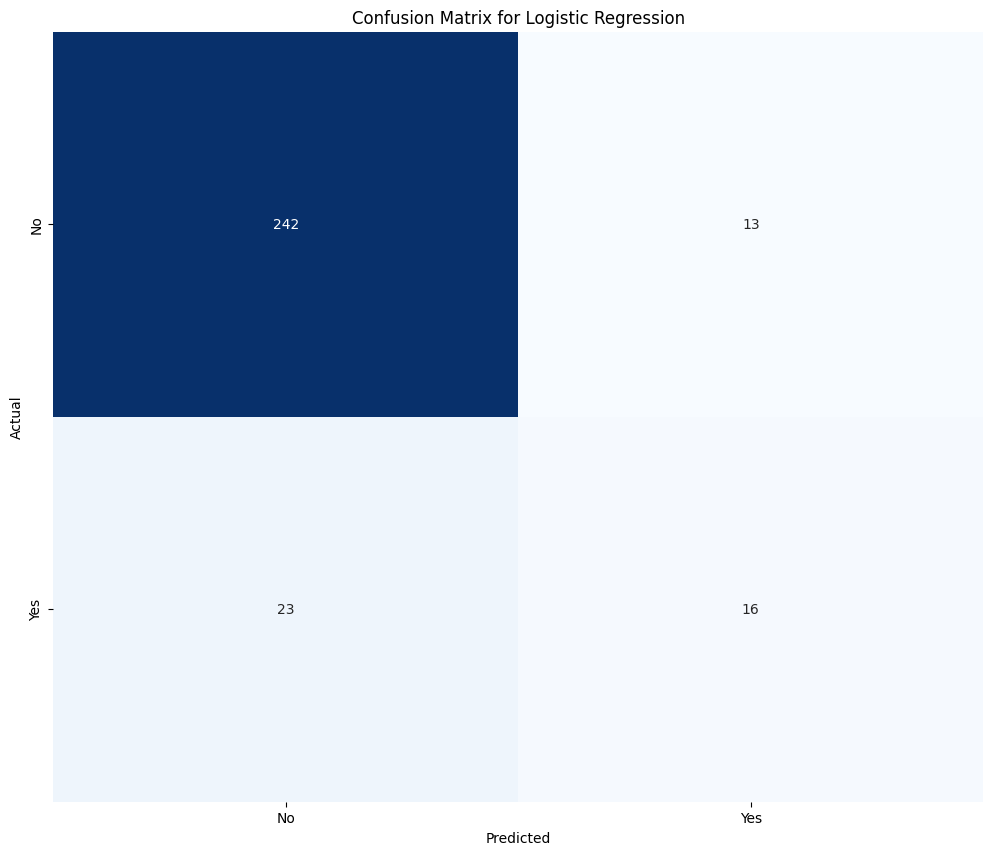

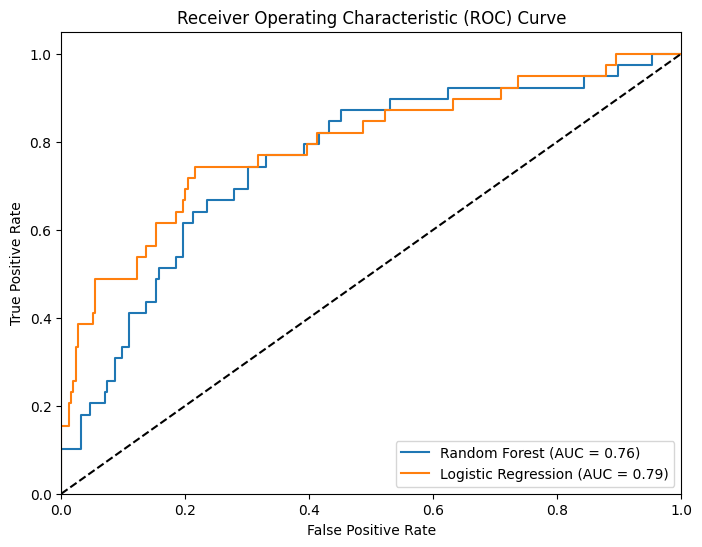

In [ ]:
# Model Performance Visualization

# Random Forest
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")

# Logistic Regression
plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression")

# ROC Curve and AUC
plt.figure(figsize=(8, 6))
for model, model_name, y_pred_prob in [(best_rf_model, 'Random Forest', best_rf_model.predict_proba(X_test)[:,1]), (best_lr_model, 'Logistic Regression', best_lr_model.predict_proba(X_test)[:,1])]:
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **Insights**

# -> Tailor programs and benefits to the specific needs of younger and single employees.

# -> Implement strategies to reduce excessive overtime to improve employee retention.

# -> Evaluate and adjust the compensation structure to be competitive and reduce attrition.

# -> Conduct targeted investigations and implement solutions in departments with higher attrition.

# -> Continuously monitor satisfaction and improve work environment, growth, and recognition.

# -> Develop onboarding and support programs for new employees to increase retention.